/var/folders/_f/vfxbwf2d1rg6vpvs2_y57cvw0000gn/T/ipykernel_29833/4117507763.py:118: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  vdw200_temp = float(temperatures_data[pressures_data == 150])
/var/folders/_f/vfxbwf2d1rg6vpvs2_y57cvw0000gn/T/ipykernel_29833/4117507763.py:122: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s" (-> marker='s'). The keyword argument will take precedence.
  plt.errorbar(


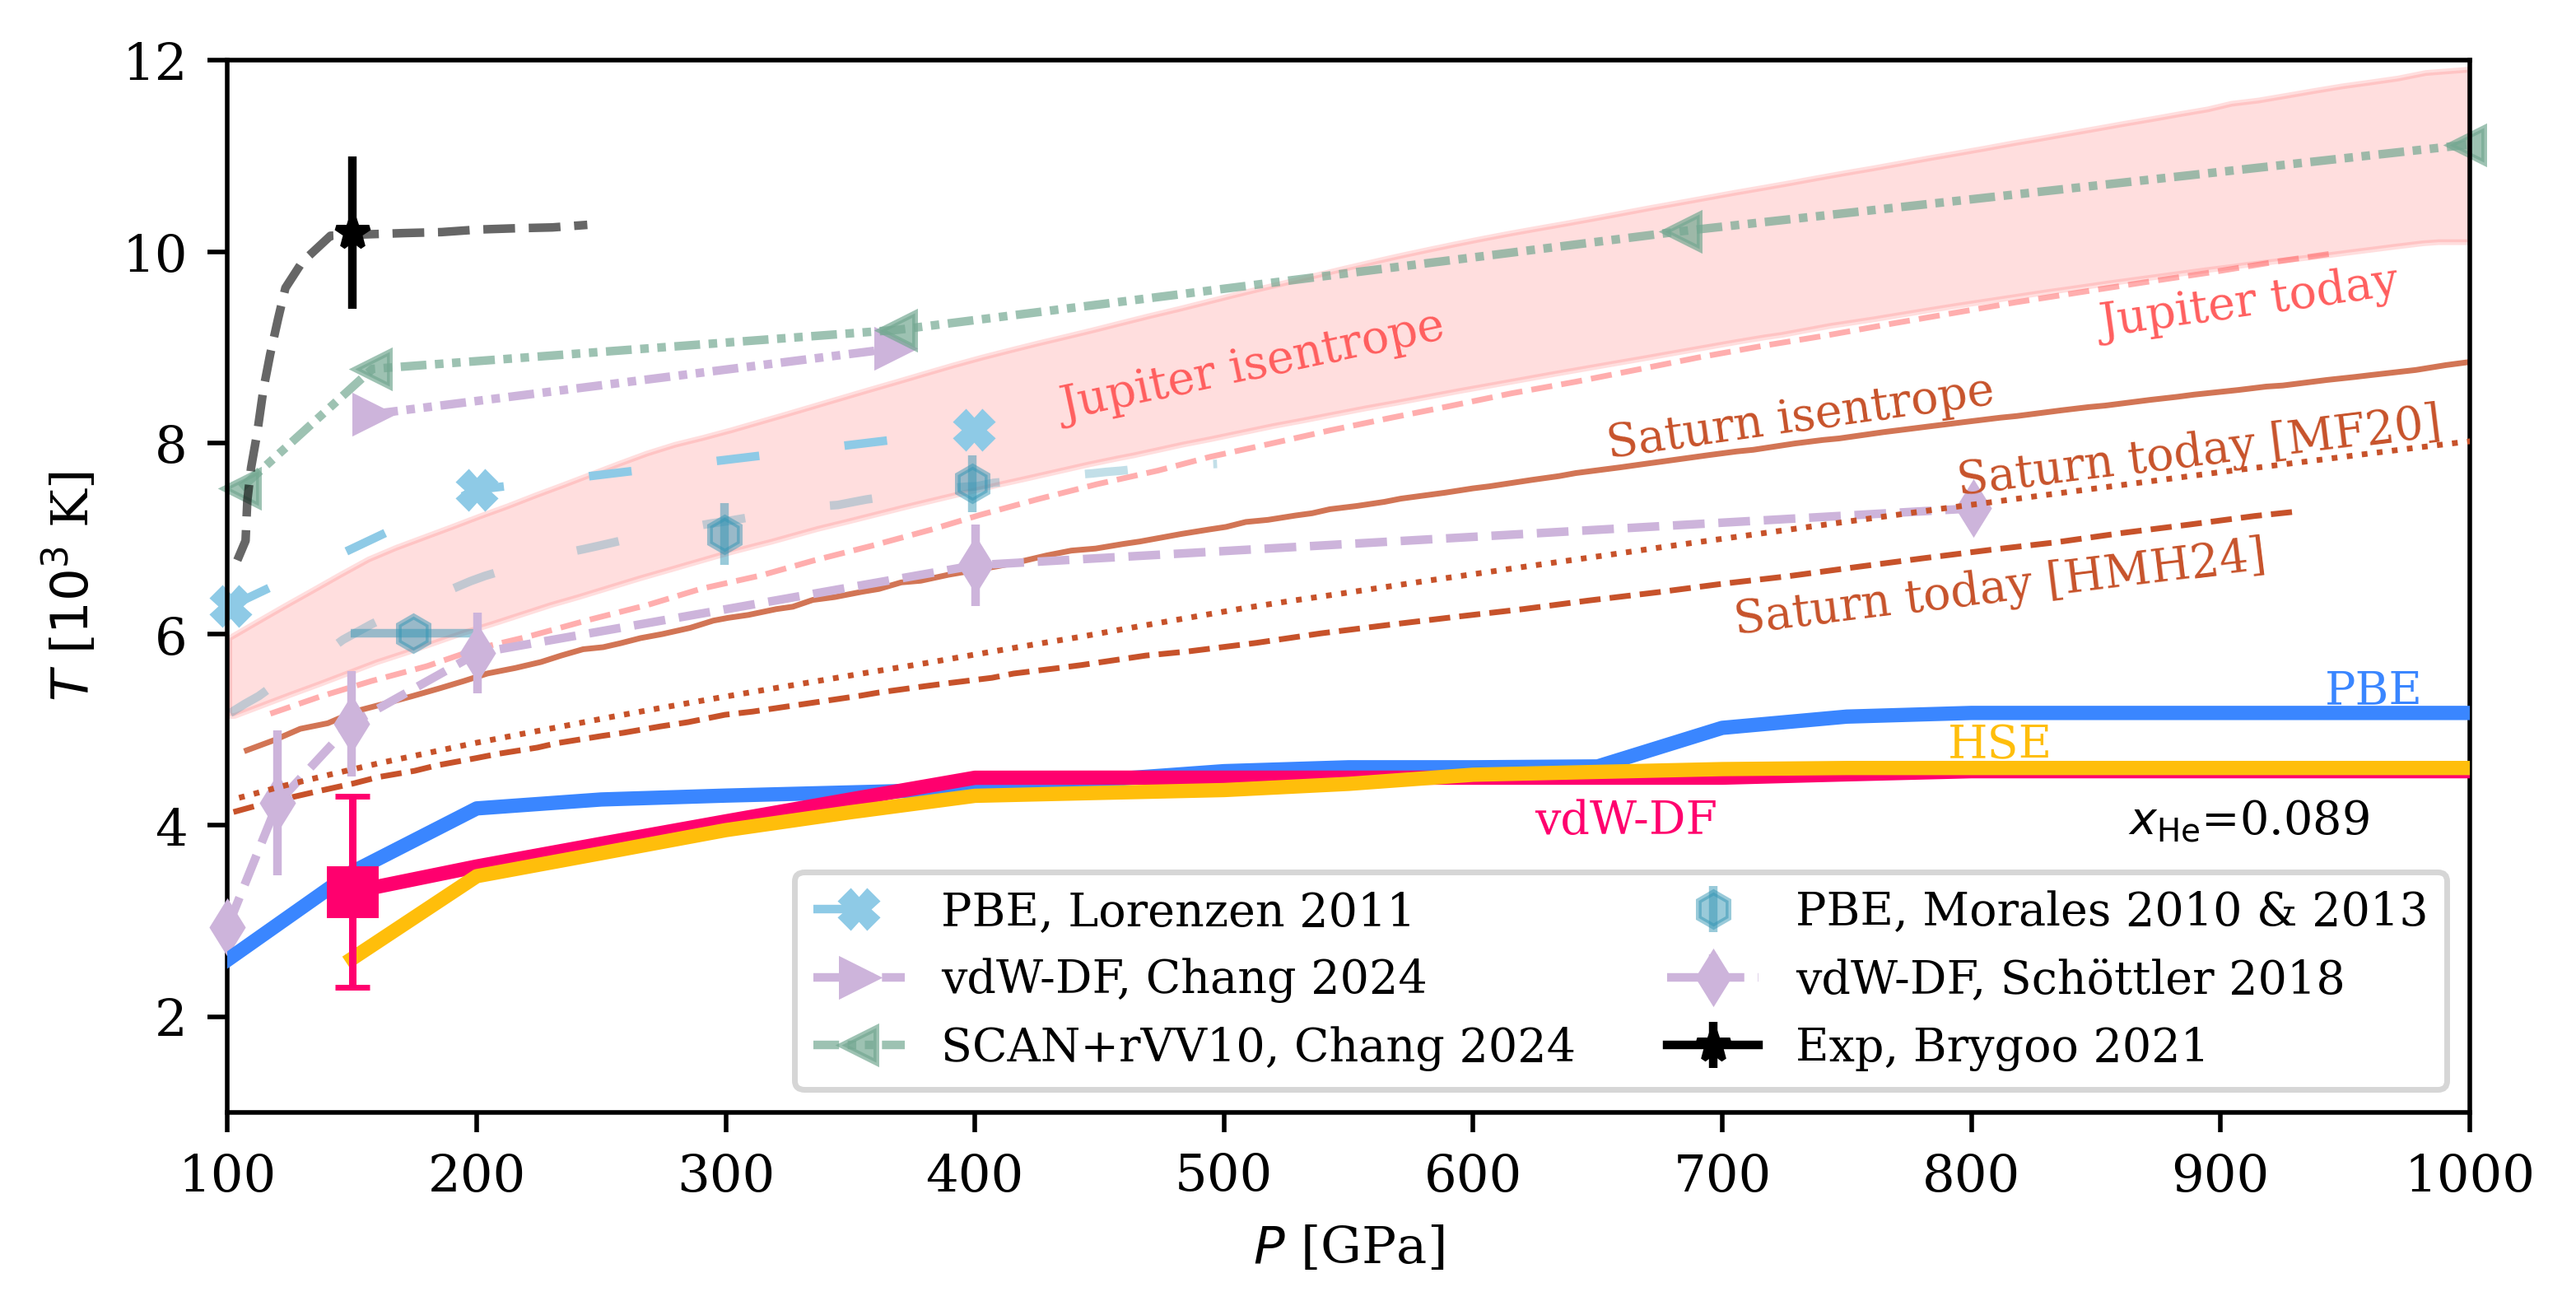

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import pandas as pd

# ======================
#  Configuration Section
# ======================
CONFIG = {
    "data_sets": ["PBE", "VDW", "HSE"],
    "colors": {
        "phase_boundary": '#2c3e50',
        "fill_above": '#f768a1',
        "fill_below": '#74a9cf',
        "jupiter": 'tomato',
        "saturn": 'orange'
    },
    "paths": {
        "data_dir": "/Users/xiaoyuwang/Project/H-He/analysis_check/",
        "planet_data": "path_to_planet_data/"
    },
    "phase_boundaries": {
        "PBE": (
            np.array([100., 150., 200., 400., 600., 800., 1000.]),
            np.array([4000, 5000., 6000., 7000., 8000., 8000., 8000.])
        ),
        "VDW": (
            np.array([100, 150., 200., 400., 600., 800., 1000.]),
            np.array([1000, 4000., 5000., 7000., 8000., 8000., 9000.])
        ),
        "HSE": (
            np.array([100., 150., 200., 400., 600., 800., 1000.]),
            np.array([1000, 3000., 4000., 6000., 7000., 8000., 8000.])
        )
    }
}

# Data for phase boundaries
phase_boundaries = {
    "PBE": (
        np.array([150., 200., 400., 600., 800., 1000.]),
        np.array([5000., 6000., 7000., 8000., 8000., 8000.])
    ),
    "VDW": (
        np.array([150., 200., 400., 600., 800., 1000.]),
        np.array([4000., 5000., 7000., 8000., 8000., 9000.])
    ), 
    "HSE": (
        np.array([200., 400., 600., 800., 1000.]),
        np.array([4000., 6000., 7000., 8000., 8000.])            
    )
}

colors = {
    "PBE": '#3A86FF',
    "VDW": '#FF006E',
    "HSE": '#FFBE0B'
}

markers = {
    "PBE": 'o',
    "VDW": 's',
    "HSE": '^'
}

color_for_Jupiter = "#ff5e5e" #'#F48892'
color_for_Saturn =  "#c7522a"

# 用mcolors.to_rgba确保alpha正确
rgba_jupiter = mcolors.to_rgba(color_for_Jupiter, alpha=0.2)
rgba_jupiter_line = mcolors.to_rgba(color_for_Jupiter, alpha=0.5)
rgba_jupiter_annot = mcolors.to_rgba(color_for_Jupiter, alpha=1.0)
rgba_saturn = mcolors.to_rgba(color_for_Saturn, alpha=1.0)
rgba_saturn_line = mcolors.to_rgba(color_for_Saturn, alpha=0.8)
rgba_saturn_annot = mcolors.to_rgba(color_for_Saturn, alpha=1.0)
rgba_saturn_mf20 = mcolors.to_rgba("#f7ad19", alpha=1.0)

# Plotting
font = {'family': 'serif', 'size': 9}
plt.rc('font', **font)

A4_width_mm = 210  # A4纸宽度（毫米）
fig_width_mm = A4_width_mm  * 0.85
fig_height_mm = A4_width_mm  * 0.65 / 1.62

# 将毫米转换为英寸（1英寸 = 25.4毫米）
fig_width_inches = fig_width_mm / 25.4
fig_height_inches = fig_height_mm / 25.4

plt.figure(figsize=(fig_width_inches, fig_height_inches), dpi=500)

vdw200_temp = None

for label, (pressures, temperatures) in phase_boundaries.items():
    if label == "VDW":
        note = "vdW-DF"
    else:
        note = label
    file_path = Path(CONFIG['paths']['data_dir']) / f"{label}_contour_data.csv"
    try:
        data = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error loading {label} data: {str(e)}")
        continue
    #plt.plot(pressures, temperatures/1e3, label=f"{note}, this work", color=colors[label], marker=markers[label], lw=2, ls='--', clip_on=False, zorder=10)

    data = data[data['x_He'] == 0.089]
    pressures_data = data['Pressure']
    temperatures_data = data['Temperature']
    plt.plot(pressures_data, temperatures_data/1e3, color=colors[label],  lw=2.5, zorder=10) # label=f"{note}, this work",

    # ===> Add vdW-DF errorbar at P=200, yerr=1 K
    if label == "VDW":
        # Try to get the T at P=200 (interpolating if not exact)
        if 150 in np.array(pressures_data):
            # Direct match
            vdw200_temp = float(temperatures_data[pressures_data == 150])
        else:
            # Interpolate
            vdw200_temp = np.interp(150, np.array(pressures_data), np.array(temperatures_data))
        plt.errorbar(
            150,
            vdw200_temp / 1e3,
            yerr=1 ,
            color=colors["VDW"],
            marker=markers["VDW"],
            markersize=8,
            capsize=3,
            elinewidth=1.3,
            fmt='s',
            zorder=15,
            #label="vdW-DF at 150 GPa"
        )

plt.annotate(rf'$x_{{\mathrm{{He}}}}$=0.089', 
           (900, 3.45),
           xytext=(5, 10),  # 调整文本偏移量
           textcoords='offset points',
           ha='center', 
           va='center',
           fontsize=8,
           color='black',
           zorder=6,
           bbox=dict(facecolor='white',  edgecolor='none') # 添加白色背景
           )

data_Lorenzen_2011 = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/Lorenzen2011-Ideal-S-PBE.csv')
data_Lorenzen_2011 = data_Lorenzen_2011.values
plt.plot(data_Lorenzen_2011[:,0]*100, data_Lorenzen_2011[:,1], label='PBE, Lorenzen 2011', ls=(0, (5, 10)), marker="X", color='#8ECAE6', markersize=6, clip_on=False)

#Morales 2013, demix. PBE, read from the csv file
data_Morales_2013_points = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/Morales_2013_nonIdeal_S.csv')
data_Morales_2013_points = data_Morales_2013_points.values

# Plot points with pressure >= 200 GPa
mask_high_pressure = data_Morales_2013_points[:,0] >= 200
high_pressure_data = data_Morales_2013_points[mask_high_pressure]
plt.errorbar(high_pressure_data[:,0], high_pressure_data[:,1]/1e3, 
             yerr=high_pressure_data[:,2]/1e3,
             label='PBE, Morales 2010 & 2013', 
             ls='', marker="h",
             color='#3596b5', alpha=0.5, markersize=6, clip_on=False)

# Plot points with pressure <= 200 GPa
mask_low_pressure = (data_Morales_2013_points[:,0] <= 200) & (data_Morales_2013_points[:,0] >= 100)
low_pressure_data = data_Morales_2013_points[mask_low_pressure]
plt.errorbar(low_pressure_data[:,0], low_pressure_data[:,1]/1e3,
             xerr=low_pressure_data[:,3],
             #label='PBE, Morales 2010 & 2013',
             ls='', marker="h",
             color='#3596b5', alpha=0.5, markersize=6, clip_on=False)

# Read and plot Morales 2013 line data
data_Morales_2013_line = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/Morales_line.csv')
data_Morales_2013_line = data_Morales_2013_line.values
mask_line = data_Morales_2013_line[:,0] >= 1.0
data_Morales_2013_line = data_Morales_2013_line[mask_line]
plt.plot(data_Morales_2013_line[:,0]*100, data_Morales_2013_line[:,1],
         ls=(0, (5, 10)), color='#3596b5', alpha=0.3, clip_on=False)

#Schöttler 2018, demix. vdW-DF
data_Schöttler_2018 = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/RR2018_points.csv')
data_Schöttler_2018 = data_Schöttler_2018.values
mask = data_Schöttler_2018[:,0] >= 1.0
data_Schöttler_2018 = data_Schöttler_2018[mask]
plt.errorbar(data_Schöttler_2018[:,0]*100, data_Schöttler_2018[:,1], yerr=data_Schöttler_2018[:,2]/1000, label='vdW-DF, Schöttler 2018', ls="dashed", marker="d", color='#cdb4db',alpha = 1.0, markersize=6,zorder=5, clip_on=False)

# Chang 2024, demix. vdW-DF DLP
data_Chang_2024 = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/Chang2024_vdW-DF.csv')
data_Chang_2024 = data_Chang_2024.values
mask = data_Chang_2024[:,0] >= 1.0
data_Chang_2024 = data_Chang_2024[mask]
plt.plot(data_Chang_2024[:,0]*100, data_Chang_2024[:,1], label='vdW-DF, Chang 2024', marker=">", color='#CDB4DB',  ls=(0, (3, 1, 1, 1, 1, 1)),  alpha=1.0, markersize=6, clip_on=False)

# Chang 2024, demix. rVV10 DLP
data_Chang_2024_rVV10 = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/Chang2024_SCAN+rVV10.csv')
data_Chang_2024_rVV10 = data_Chang_2024_rVV10.values
mask = data_Chang_2024_rVV10[:,0] >= 1.0
data_Chang_2024_rVV10 = data_Chang_2024_rVV10[mask]
plt.plot(data_Chang_2024_rVV10[:,0]*100, data_Chang_2024_rVV10[:,1], label='SCAN+rVV10, Chang 2024', marker="<", color='#74a892', ls=(0, (3, 1, 1, 1, 1, 1)),  alpha=0.7, markersize=6, clip_on=False)

# Jupiter adiabatic data
data_Jupiter_adiabatic_Militzer = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/Jupiter_Militzer.csv').values
mask = data_Jupiter_adiabatic_Militzer[:,0] >= 1.0
data_Jupiter_adiabatic_Militzer = data_Jupiter_adiabatic_Militzer[mask]

data_Jupiter_adiabatic_Nettelmann = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/Jupiter_Nettelmann.csv').values
mask = data_Jupiter_adiabatic_Nettelmann[:,0] >= 1.0
data_Jupiter_adiabatic_Nettelmann = data_Jupiter_adiabatic_Nettelmann[mask]

data_Jupiter_adiabatic_RR_2018 = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/Redmer_2018_Jupiter_ada.csv').values
mask = data_Jupiter_adiabatic_RR_2018[:,0] >= 1.0
data_Jupiter_adiabatic_RR_2018 = data_Jupiter_adiabatic_RR_2018[mask]

# Create unified pressure grid
pressures = np.union1d(
    np.union1d(
        data_Jupiter_adiabatic_Nettelmann[:,0]*100,
        data_Jupiter_adiabatic_Militzer[:,0]*100
    ),
    data_Jupiter_adiabatic_RR_2018[:,0]*100
)

# Interpolate temperatures to unified pressure grid
interp_temp_N = np.interp(pressures,
                         data_Jupiter_adiabatic_Nettelmann[:,0]*100,
                         data_Jupiter_adiabatic_Nettelmann[:,1])
interp_temp_M = np.interp(pressures,
                         data_Jupiter_adiabatic_Militzer[:,0]*100,
                         data_Jupiter_adiabatic_Militzer[:,1])
interp_temp_RR = np.interp(pressures,
                         data_Jupiter_adiabatic_RR_2018[:,0]*100,
                         data_Jupiter_adiabatic_RR_2018[:,1])

# Calculate upper and lower bounds
upper_bound = np.maximum(np.maximum(interp_temp_N, interp_temp_M), interp_temp_RR)
lower_bound = np.minimum(np.minimum(interp_temp_N, interp_temp_M), interp_temp_RR)

# Plot filled region between upper and lower bounds, 用rgba_jupiter
plt.fill_between(
    pressures,
    lower_bound,
    upper_bound,
    color=rgba_jupiter,
    zorder=1,
    clip_on=True
)

####
data_Jupiter_today_2024 = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies_check/Jupiter_today_HMH24.csv')
data_Jupiter_today_2024 = data_Jupiter_today_2024.values
mask = data_Jupiter_today_2024[:,0] >= 1.0
data_Jupiter_today_2024 = data_Jupiter_today_2024[mask]
plt.plot(data_Jupiter_today_2024[:,0]*100, data_Jupiter_today_2024[:,1]/1000 ,  ls='dashed', color=rgba_jupiter_line, linewidth=1,  markersize=6, clip_on=True)    

data_Saturn_today_2024 = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies_check/Saturn_today_HMH24.csv')
data_Saturn_today_2024 = data_Saturn_today_2024.values
mask = data_Saturn_today_2024[:,0] >= 1.0
data_Saturn_today_2024 = data_Saturn_today_2024[mask]
plt.plot(data_Saturn_today_2024[:,0]*100, data_Saturn_today_2024[:,1]/1000 ,  ls='dashed', color=rgba_saturn, linewidth=1, markersize=6, clip_on=True)    

   


data_Saturn_present = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies_check/Saturn_CM_JF_2020.csv')
data_Saturn_present = data_Saturn_present.values
mask = data_Saturn_present[:,0] >= 1.0
data_Saturn_present = data_Saturn_present[mask]
plt.plot(data_Saturn_present[:,0]*100, data_Saturn_present[:,1],  ls="dotted", color=rgba_saturn, linewidth=1, markersize=6, zorder=15, clip_on=True)    

data_Saturn_adiabatic_2024 = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies_check/Saturn_Nettelmann.csv')
data_Saturn_adiabatic_2024 = data_Saturn_adiabatic_2024.values
mask = data_Saturn_adiabatic_2024[:,0] >= 1.0
data_Saturn_adiabatic_2024 = data_Saturn_adiabatic_2024[mask]
plt.plot(data_Saturn_adiabatic_2024[:,0]*100, data_Saturn_adiabatic_2024[:,1], ls='-', color=rgba_saturn_line, linewidth=1,  markersize=6, clip_on=True)    

text_fontsize = 8
plt.annotate('Jupiter isentrope', 
    xy=(500, 8.2),
    xytext=(5, 10), 
    textcoords='offset points',
    rotation=12,
    rotation_mode='anchor',
    transform_rotates_text=True,  
    ha='center', 
    va='center',
    color=rgba_jupiter_annot, 
    fontsize=text_fontsize)

plt.annotate('Jupiter today', 
    xy=(900, 8.2),
    xytext=(5, 21), 
    textcoords='offset points',
    rotation=8,
    rotation_mode='anchor',
    transform_rotates_text=True,  
    ha='center', 
    va='center',
    color=rgba_jupiter_annot, 
    fontsize=text_fontsize)

plt.annotate('Saturn isentrope', 
    xy=(720,7.3),
    xytext=(5, 16), 
    textcoords='offset points',
    rotation=8,
    rotation_mode='anchor',
    transform_rotates_text=True,  
    ha='center', 
    va='center',
    color=rgba_saturn_annot, 
    fontsize=text_fontsize)

plt.annotate('Saturn today [HMH24]', 
    xy=(800,5.7),
    xytext=(5, 13), 
    textcoords='offset points',
    rotation=7,
    rotation_mode='anchor',
    transform_rotates_text=True,  
    ha='center', 
    va='center',
    color=rgba_saturn_annot, 
    fontsize=text_fontsize)

plt.annotate('Saturn today [MF20]', 
    xy=(880, 7),
    xytext=(5, 15), 
    textcoords='offset points',
    rotation=7,
    rotation_mode='anchor',
    transform_rotates_text=True,  
    ha='center', 
    va='center',
    color=rgba_saturn_annot, 
    fontsize=text_fontsize,
    #put it on the front layer
    zorder=10
)

#########

plt.annotate('HSE', 
    xy=(800,3.75),
    xytext=(5, 18), 
    textcoords='offset points',
    rotation=0,
    rotation_mode='anchor',
    transform_rotates_text=True,  
    ha='center', 
    va='center',
    color='#FFBE0B', 
    fontsize=8)

plt.annotate('vdW-DF', 
    xy=(650,2.9),
    xytext=(5, 19), 
    textcoords='offset points',
    rotation=0,
    rotation_mode='anchor',
    transform_rotates_text=True,  
    ha='center', 
    va='center',
    color='#FF006E', 
    fontsize=8)

plt.annotate('PBE', 
    xy=(950,4.5),
    xytext=(5, 15), 
    textcoords='offset points',
    rotation=0,
    rotation_mode='anchor',
    transform_rotates_text=True,  
    ha='center', 
    va='center',
    color='#3A86FF', 
    fontsize=8)

#exp 
data_Brygoo_2021 = pd.read_csv('/Users/xiaoyuwang/Project/H-He/Previous_Studies/Exp_lines.csv')
data_Brygoo_2021 = data_Brygoo_2021.values
mask = data_Brygoo_2021[:,0] >= 1
data_Brygoo_2021 = data_Brygoo_2021[mask]
plt.plot(data_Brygoo_2021[:,0]*100, data_Brygoo_2021[:,1],  ls="dashed",  color='black',  alpha=0.6,  clip_on=False)

plt.errorbar(150, 10.200, yerr=0.8, color='black', marker='*', label='Exp, Brygoo 2021', markersize=6)
plt.errorbar(93, 4.700, yerr=0.000000000000000, color='black', marker='*',  markersize=6)

# vdW-DF
#plt.plot(100, 1, color="#FF006E", marker="s", markersize=6, clip_on=False, fillstyle='none')
# HSE, 
#plt.plot(100, 1, color="#FFBE0B", marker="^", markersize=6, clip_on=False, fillstyle='none')

# Adding labels, title, and legend
ax = plt.gca()  # Get current axes
ax.set_axisbelow(True)
ax.set_zorder(1)
plt.ylabel(r"$T$ [$10^3$ K]")
plt.xlabel(r"$P$ [GPa]")
plt.grid(False)
plt.legend(ncol=2, fontsize=8)

plt.xlim(100, 1000)
plt.ylim(1, 12)




# Show the plot
plt.savefig('/Users/xiaoyuwang/Project/H-He/H-He-demixing/Figs/Fig2_compare.pdf', dpi=500, bbox_inches='tight')
plt.show()


Generating Figure 2: Immiscible Boundary Subplots...


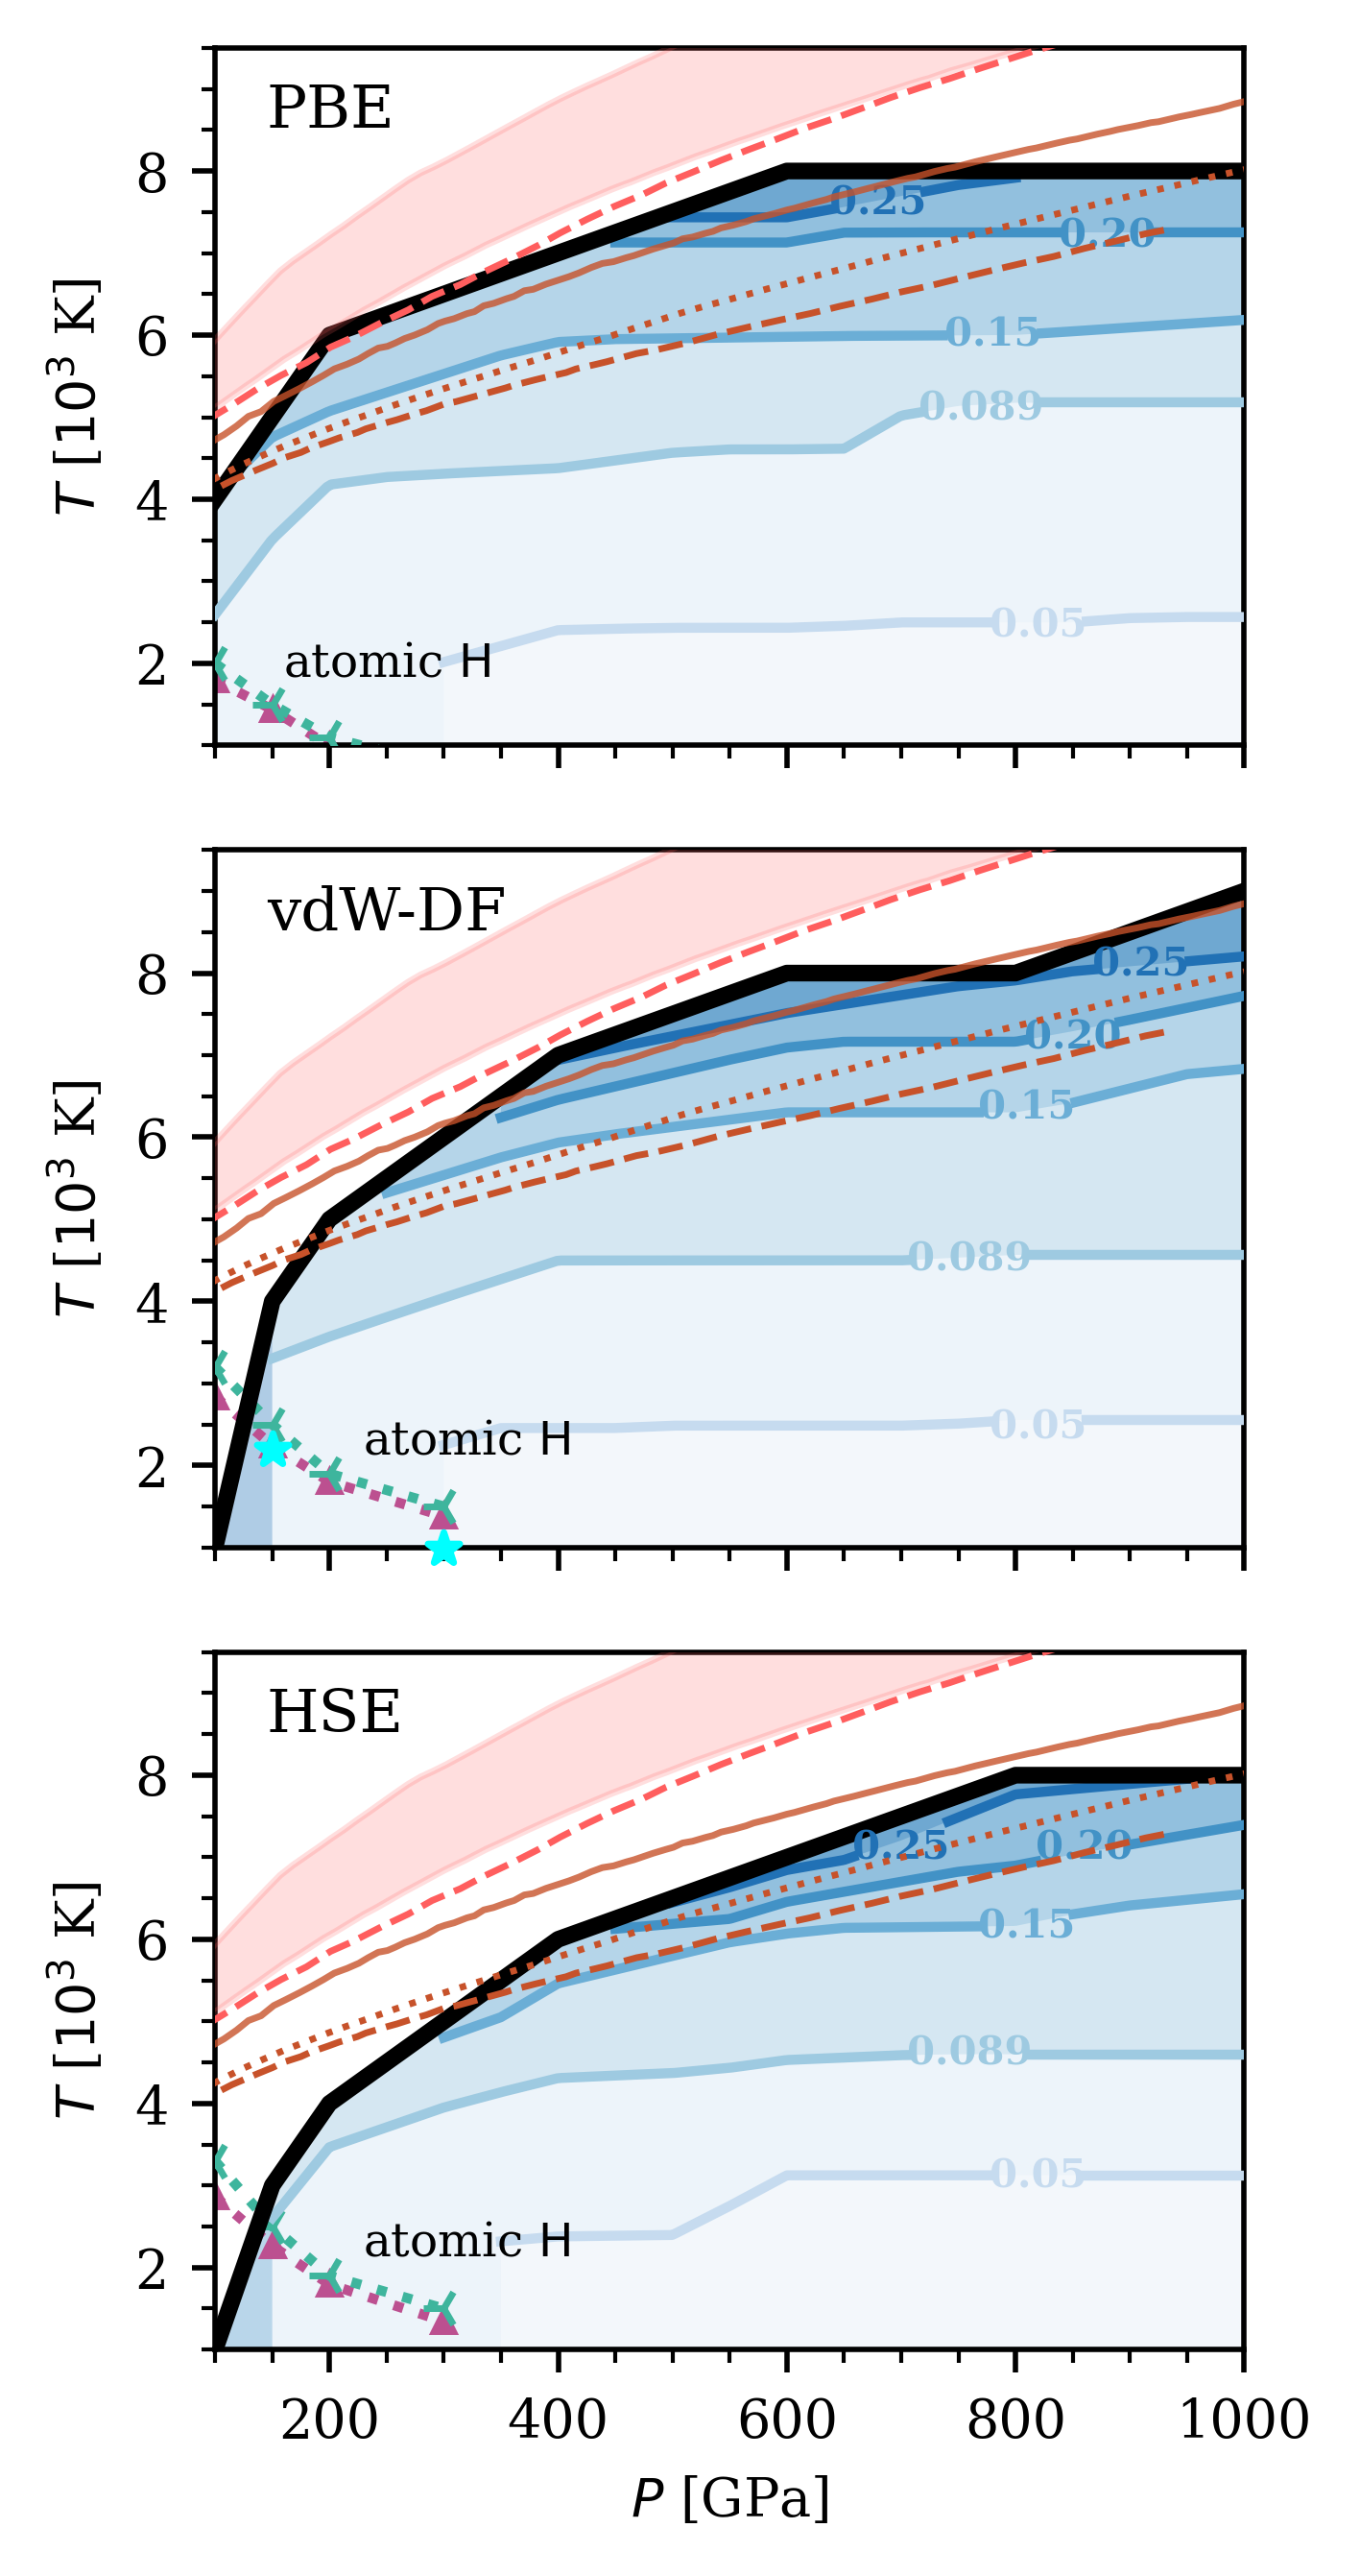

Figure 2 saved to /Users/xiaoyuwang/Project/H-He/H-He-demixing/Figs/Fig2_immiscible_subplots.pdf

Both plots have been generated and saved successfully.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from scipy.interpolate import interp1d

font = {'family': 'serif', 'size': 9}
plt.rc('font', **font)
    
# ==============================================================================
# 1. UNIFIED CONFIGURATION
# All settings, paths, and styles are defined here for consistency.
# ==============================================================================

# --- File Paths (Update these to your local directory structure) ---
# It's recommended to use a single base path for data.
BASE_DATA_DIR = Path("/Users/xiaoyuwang/Project/H-He/")
PATHS = {
    "analysis": BASE_DATA_DIR / "analysis_check/",
    "previous_studies": BASE_DATA_DIR / "Previous_Studies_check/",
    "output_figs": BASE_DATA_DIR / "H-He-demixing/Figs/"
}
# Ensure the output directory exists
PATHS["output_figs"].mkdir(parents=True, exist_ok=True)


# --- Color & Style Definitions ---
# Colors for different functionals used in Plot 1
FUNC_COLORS = {
    "PBE": '#3A86FF',
    "VDW": '#FF006E',
    "HSE": '#FFBE0B'
}

# Markers for different functionals used in Plot 1
FUNC_MARKERS = {
    "PBE": 'o',
    "VDW": 's',
    "HSE": '^'
}

# Colors for Jupiter and Saturn Isentropes/Profiles
COLOR_JUPITER = "#ff5e5e"
COLOR_SATURN = "#c7522a"
COLOR_SATURN_MF20 = "#c7522a"

# Generate RGBA colors with alpha for filled regions and lines
RGBA_JUPITER = mcolors.to_rgba(COLOR_JUPITER, alpha=0.2)
RGBA_JUPITER_LINE = mcolors.to_rgba(COLOR_JUPITER, alpha=0.5)
RGBA_JUPITER_ANNOT = mcolors.to_rgba(COLOR_JUPITER, alpha=1.0)
RGBA_SATURN = mcolors.to_rgba(COLOR_SATURN, alpha=1.0)
RGBA_SATURN_LINE = mcolors.to_rgba(COLOR_SATURN, alpha=0.8)
RGBA_SATURN_ANNOT = mcolors.to_rgba(COLOR_SATURN, alpha=1.0)
RGBA_SATURN_MF20 = mcolors.to_rgba(COLOR_SATURN_MF20, alpha=1.0)

# Color palette for x_He contours in Plot 2
CUSTOM_PURPLES_PALETTE = ['#c6dbef','#9ecae1','#6baed6','#4292c6','#2171b5','#084594']

# --- Phase Boundary Data (Using the more complete dataset from the second script) ---
PHASE_BOUNDARIES = {
    "PBE": (
        np.array([100., 150., 200., 400., 600., 800., 1000.]),
        np.array([4000, 5000., 6000., 7000., 8000., 8000., 8000.])
    ),
    "VDW": (
        np.array([100, 150., 200., 400., 600., 800., 1000.]),
        np.array([1000, 4000., 5000., 7000., 8000., 8000., 9000.])
    ),
    "HSE": (
        np.array([100., 150., 200., 400., 600., 800., 1000.]),
        np.array([1000, 3000., 4000., 6000., 7000., 8000., 8000.])
    )
}

cheng2020 = pd.read_csv(
    "/Users/xiaoyuwang/Project/H-He/H_atomization/H_Atom_boundary_Cheng2020.csv",
    header=None, names=["P", "T"]
)
# ==============================================================================
# 2. DATA LOADING AND PREPARATION
# Load all data from CSV files once to be used by both plots.
# ==============================================================================

def load_all_data():
    """Loads and prepares all datasets required for plotting."""
    data = {}
    
    # Load contour data for each functional
    for label in ["PBE", "VDW", "HSE"]:
        try:
            data[f"{label}_contour"] = pd.read_csv(PATHS["analysis"] / f"{label}_contour_data.csv")
        except Exception as e:
            print(f"Error loading {label}_contour_data.csv: {e}")
            data[f"{label}_contour"] = None
            
    # Load data from previous studies
    try:
        data['Lorenzen_2011'] = pd.read_csv(PATHS["previous_studies"] / 'Lorenzen2011-Ideal-S-PBE.csv').values
        data['Morales_2013_points'] = pd.read_csv(PATHS["previous_studies"] / 'Morales_2013_nonIdeal_S.csv').values
        data['Morales_2013_line'] = pd.read_csv(PATHS["previous_studies"] / 'Morales_line.csv').values
        data['Schottler_2018'] = pd.read_csv(PATHS["previous_studies"] / 'RR2018_points.csv').values
        data['Chang_2024_vdW'] = pd.read_csv(PATHS["previous_studies"] / 'Chang2024_vdW-DF.csv').values
        data['Chang_2024_rVV10'] = pd.read_csv(PATHS["previous_studies"] / 'Chang2024_SCAN+rVV10.csv').values
        data['Brygoo_2021_exp'] = pd.read_csv(PATHS["previous_studies"] / 'Exp_lines.csv').values
        
        # Load Jupiter and Saturn data
        data['Jupiter_Militzer'] = pd.read_csv(PATHS["previous_studies"] / 'Jupiter_Militzer.csv').values
        data['Jupiter_Nettelmann'] = pd.read_csv(PATHS["previous_studies"] / 'Jupiter_Nettelmann.csv').values
        data['Jupiter_RR_2018'] = pd.read_csv(PATHS["previous_studies"] / 'Redmer_2018_Jupiter_ada.csv').values
        data['Jupiter_today_2024'] = pd.read_csv(PATHS["previous_studies"] / 'Jupiter_today_HMH24.csv').values 
        data['Saturn_today_2024'] = pd.read_csv(PATHS["previous_studies"] / 'Saturn_today_HMH24.csv').values
        data['Saturn_present_MF20'] = pd.read_csv(PATHS["previous_studies"] / 'Saturn_CM_JF_2020.csv').values
        data['Saturn_isentrope_Nettelmann'] = pd.read_csv(PATHS["previous_studies"] / 'Saturn_Nettelmann.csv').values

    except Exception as e:
        print(f"An error occurred during file loading: {e}")
        return None

    # --- Pre-process Jupiter adiabat filled region ---
    # Create unified pressure grid
    pressures = np.union1d(
        np.union1d(
            data['Jupiter_Nettelmann'][:, 0] * 100,
            data['Jupiter_Militzer'][:, 0] * 100
        ),
        data['Jupiter_RR_2018'][:, 0] * 100
    )
    # Interpolate temperatures to unified pressure grid
    interp_temp_N = np.interp(pressures, data['Jupiter_Nettelmann'][:, 0] * 100, data['Jupiter_Nettelmann'][:, 1])
    interp_temp_M = np.interp(pressures, data['Jupiter_Militzer'][:, 0] * 100, data['Jupiter_Militzer'][:, 1])
    interp_temp_RR = np.interp(pressures, data['Jupiter_RR_2018'][:, 0] * 100, data['Jupiter_RR_2018'][:, 1])
    # Calculate upper and lower bounds
    data['Jupiter_adiabat_pressures'] = pressures
    data['Jupiter_adiabat_upper'] = np.maximum(np.maximum(interp_temp_N, interp_temp_M), interp_temp_RR)
    data['Jupiter_adiabat_lower'] = np.minimum(np.minimum(interp_temp_N, interp_temp_M), interp_temp_RR)
        
    return data

# ==============================================================================
# 3. PLOTTING FUNCTION FOR FIGURE 1 (Comparison Plot)
# This function reproduces the first figure from the original script.
# ==============================================================================
def create_immiscible_subplots(data):
    """Generates and saves the 3x1 subplot figure of immiscible boundaries."""
    print("Generating Figure 2: Immiscible Boundary Subplots...")

    font = {'family': 'serif', 'size': 8}
    plt.rc('font', **font)

    # --- Figure Size ---
    subplot_width_pt = 200
    subplot_height_pt = 150
    subplot_width_in = subplot_width_pt / 72.27
    subplot_height_in = subplot_height_pt / 72.27

    fig, axes = plt.subplots(
        nrows=3, ncols=1,
        figsize=(subplot_width_in, subplot_height_in * 3),
        sharex=True, dpi=500
    )
    plt.subplots_adjust(hspace=0.15)
    plot_axes = axes.flatten()

    # --- Determine universal color mapping for x_He ---
    all_x_he = set()
    for dataset in ["PBE", "VDW", "HSE"]:
        contour_data = data.get(f"{dataset}_contour")
        if contour_data is not None:
            all_x_he.update(contour_data['x_He'].unique())
    sorted_x_he = sorted(all_x_he)
    color_mapping = dict(zip(sorted_x_he, sns.color_palette(CUSTOM_PURPLES_PALETTE, n_colors=len(sorted_x_he))))

    # --- Plotting Loop for each subplot ---
    for idx, (ax, dataset_name) in enumerate(zip(plot_axes, ["PBE", "VDW", "HSE"])):
        ax.grid(False)
        contour_data = data.get(f"{dataset_name}_contour")
        if contour_data is None:
            continue

        # Plot main phase boundary
        boundary = PHASE_BOUNDARIES[dataset_name]
        boundary_Pre, boundary_Tem_1k = boundary[0], boundary[1] / 1e3
        ax.plot(boundary_Pre, boundary_Tem_1k, 'k-', zorder=11, linewidth=2.5)

        # Plot x_He contours and fill regions
        hue_groups = contour_data.groupby('x_He')
        boundary_interp = interp1d(boundary_Pre, boundary_Tem_1k, bounds_error=False, fill_value="extrapolate")

        for group_val, subset in hue_groups:
            if subset.empty:
                continue

            subset = subset.sort_values('Pressure').drop_duplicates('Pressure').reset_index(drop=True)
            color = color_mapping.get(group_val, 'gray')

            # Manual text locations
            label_pos = {
                ("PBE", 0.25): (680, 7.60),
                ("PBE", 0.20): (880, 7.20),
                ("PBE", 0.15): (780, 6.00),
                ("PBE", 0.089): (770, 5.10),
                ("PBE", 0.05): (820, 2.45),

                ("VDW", 0.25): (910, 8.10),
                ("VDW", 0.20): (850, 7.20),
                ("VDW", 0.15): (810, 6.35),
                ("VDW", 0.089): (760, 4.50),
                ("VDW", 0.05): (820, 2.45),

                ("HSE", 0.25): (700, 7.10),
                ("HSE", 0.20): (860, 7.10),
                ("HSE", 0.15): (810, 6.15),
                ("HSE", 0.089): (760, 4.60),
                ("HSE", 0.05): (820, 3.10),
            }

            x_text, y_text = label_pos.get(
                (dataset_name, round(float(group_val), 3)),
                (subset['Pressure'].iloc[-1] * 0.92, subset['Temperature'].iloc[-1] / 1e3)
            )

            # Gap width in GPa, centered on text
            gap_width_map = {
                ("PBE", 0.25): 45,
                ("PBE", 0.20): 42,
                ("PBE", 0.15): 40,
                ("PBE", 0.089): 38,
                ("PBE", 0.05): 35,

                ("VDW", 0.25): 40,
                ("VDW", 0.20): 38,
                ("VDW", 0.15): 36,
                ("VDW", 0.089): 34,
                ("VDW", 0.05): 32,

                ("HSE", 0.25): 38,
                ("HSE", 0.20): 36,
                ("HSE", 0.15): 34,
                ("HSE", 0.089): 34,
                ("HSE", 0.05): 32,
            }
            gap_width = gap_width_map.get((dataset_name, round(float(group_val), 3)), 36)

            # Build a denser line so the broken segment looks smoother
            x_raw = subset['Pressure'].to_numpy(dtype=float)
            y_raw = (subset['Temperature'].to_numpy(dtype=float)) / 1e3

            if len(x_raw) >= 3:
                x_line = np.linspace(x_raw.min(), x_raw.max(), 240)
                y_line = np.interp(x_line, x_raw, y_raw)
            else:
                x_line = x_raw
                y_line = y_raw

            # Fill regions first
            if np.isclose(group_val, 0.05):
                add_data_P = np.linspace(100, x_line.min(), 120)
                subset_p = np.concatenate((add_data_P, x_line))
                subset_T = np.concatenate((np.zeros_like(add_data_P), y_line))
                boundary_temperatures = boundary_interp(subset_p)

                ax.fill_between(
                    subset_p, subset_T, boundary_temperatures,
                    color=color, alpha=0.30, edgecolor='none', zorder=2
                )
                ax.fill_between(
                    subset_p, 0, subset_T,
                    color=color, alpha=0.20, edgecolor='none', zorder=2
                )
            else:
                boundary_temperatures = boundary_interp(x_line)
                ax.fill_between(
                    x_line, y_line, boundary_temperatures,
                    color=color, alpha=0.30, edgecolor='none', zorder=2
                )

            # Draw line with a gap centered at the text position
            x_left = x_text - gap_width / 2
            x_right = x_text + gap_width / 2

            mask_left = x_line < x_left
            mask_right = x_line > x_right

            ax.plot(x_line[mask_left], y_line[mask_left], color=color, lw=1.5, zorder=6)
            ax.plot(x_line[mask_right], y_line[mask_right], color=color, lw=1.5, zorder=6, label="_nolegend_")

            # Label text
            if np.isclose(group_val, 0.089):
                label = "0.089"
            elif np.isclose(group_val, 0.05):
                label = "0.05"
            else:
                label = f"{group_val:.2f}"

            ax.text(
                x_text, y_text, label,
                weight='bold', color=color, fontsize=6,
                ha='center', va='center', zorder=12
            )

        # --- Plot Jupiter and Saturn profiles on each subplot ---
        ax.fill_between(
            data['Jupiter_adiabat_pressures'],
            data['Jupiter_adiabat_lower'],
            data['Jupiter_adiabat_upper'],
            color=RGBA_JUPITER, zorder=1, clip_on=True
        )

        d_jup = data['Jupiter_today_2024']
        ax.plot(d_jup[:, 0] * 100, d_jup[:, 1] / 1000 + 1, ls='dashed', color=COLOR_JUPITER, linewidth=1, alpha=1, clip_on=True)

        d_sat = data['Saturn_today_2024']
        ax.plot(d_sat[:, 0] * 100, d_sat[:, 1] / 1000 + 1, ls='dashed', color=COLOR_SATURN, linewidth=1, clip_on=True)

        d_sat_mf20 = data['Saturn_present_MF20']
        ax.plot(d_sat_mf20[:, 0] * 100, d_sat_mf20[:, 1], ls="dotted", color=COLOR_SATURN_MF20, linewidth=1, clip_on=True)

        d_sat_isen = data['Saturn_isentrope_Nettelmann']
        ax.plot(d_sat_isen[:, 0] * 100, d_sat_isen[:, 1], ls='-', color=COLOR_SATURN, linewidth=1, alpha=0.8, clip_on=True)




        # --- Subplot-specific annotations ---
        if dataset_name == "PBE":
            ax.plot([100, 150, 200, 300], [2.0, 1.5, 1.1, 0.74], color='#3eb59d', marker="3", ls='dotted', markersize=6, clip_on=True, fillstyle='none', zorder=3)
            ax.plot([100., 150., 200., 300.], [t/1000 for t in [1795.91, 1437.13, 991.08, 708.80]], marker="^", markersize=3, linestyle='dotted', color='#bc5090')
            ax.annotate(r'atomic $\rm{H}$', xy=(250, 2.0), rotation=0, ha='center', va='center', color='black', fontsize=7)
            ax.text(0.05, 0.95, dataset_name, transform=ax.transAxes, ha='left', va='top', fontsize=9)

        elif dataset_name == "HSE":
            ax.fill_between([100, 150], [0, 1], [1, 3], color="#4292c6", alpha=0.3, zorder=2, edgecolor='none')
            ax.plot([100, 150, 200, 300], [3.3, 2.5, 1.9, 1.5], color='#3eb59d', marker="3", ls='dotted', markersize=6, clip_on=True, fillstyle='none', zorder=3)
            ax.plot([100., 150., 200., 300.], [t/1000 for t in [2864.74, 2263.12, 1794.11, 1344.13]], marker="^", markersize=3, linestyle='dotted', color='#bc5090')
            ax.annotate(r'atomic $\rm{H}$', xy=(320, 2.3), rotation=0, ha='center', va='center', color='black', fontsize=7)
            ax.text(0.05, 0.95, dataset_name, transform=ax.transAxes, ha='left', va='top', fontsize=9)

        elif dataset_name == "VDW":
            ax.fill_between([100, 150], [0, 1], [1, 4], color="#2171b5", alpha=0.3, zorder=2, edgecolor='none')
            ax.plot([100, 150, 200, 300], [3.2, 2.5, 1.9, 1.5], color='#3eb59d', marker="3", ls='dotted', markersize=6, clip_on=True, fillstyle='none', zorder=3)
            ax.plot([100., 150., 200., 300.], [2838.62/1000, 2244.41/1000, 1801.67/1000, 1380.80/1000], marker="^", markersize=3, linestyle='dotted', color='#bc5090')
            ax.annotate(r'atomic $\rm{H}$', xy=(320, 2.3), rotation=0, ha='center', va='center', color='black', fontsize=7)
            ax.text(0.05, 0.95, "vdW-DF", transform=ax.transAxes, ha='left', va='top', fontsize=9)

        # --- Axes settings ---
        ax.set(xlim=(100, 1000), ylim=(1, 9.5))
        ax.yaxis.set_major_locator(plt.MultipleLocator(2))
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.minorticks_on()
        ax.tick_params(which='both', top=False, right=False)
        ax.set_ylabel(r'$T$ [$10^3$ K]', fontsize=8)

        ax.label_outer()

    # --- Final Touches for the whole figure ---
    axes[-1].set_xlabel(r'$P$ [GPa]')

    # --- Save Figure ---
    output_path = PATHS["output_figs"] / 'Fig2_immiscible_subplots.pdf'
    plt.savefig(output_path, dpi=500, bbox_inches='tight')
    plt.show()
    print(f"Figure 2 saved to {output_path}")
    plt.close(fig)



# ==============================================================================
# 4. PLOTTING FUNCTION FOR FIGURE 2 (Immiscible Boundary Subplots)
# This function reproduces the second figure from the original script.
# ==============================================================================
def create_immiscible_subplots(data):
    """Generates and saves the 3x1 subplot figure of immiscible boundaries."""
    print("Generating Figure 2: Immiscible Boundary Subplots...")

    font = {'family': 'serif', 'size': 8}
    plt.rc('font', **font)

    # --- Figure Size ---
    subplot_width_pt = 200
    subplot_height_pt = 150
    subplot_width_in = subplot_width_pt / 72.27
    subplot_height_in = subplot_height_pt / 72.27

    fig, axes = plt.subplots(
        nrows=3, ncols=1,
        figsize=(subplot_width_in, subplot_height_in * 3),
        sharex=True, dpi=500
    )
    plt.subplots_adjust(hspace=0.15)
    plot_axes = axes.flatten()

    # --- Determine universal color mapping for x_He ---
    all_x_he = set()
    for dataset in ["PBE", "VDW", "HSE"]:
        contour_data = data.get(f"{dataset}_contour")
        if contour_data is not None:
            all_x_he.update(contour_data['x_He'].unique())
    sorted_x_he = sorted(all_x_he)
    color_mapping = dict(zip(sorted_x_he, sns.color_palette(CUSTOM_PURPLES_PALETTE, n_colors=len(sorted_x_he))))

    # --- Plotting Loop for each subplot ---
    for idx, (ax, dataset_name) in enumerate(zip(plot_axes, ["PBE", "VDW", "HSE"])):



        ax.grid(False)
        contour_data = data.get(f"{dataset_name}_contour")
        if contour_data is None:
            continue

        # Plot main phase boundary
        boundary = PHASE_BOUNDARIES[dataset_name]
        boundary_Pre, boundary_Tem_1k = boundary[0], boundary[1] / 1e3
        ax.plot(boundary_Pre, boundary_Tem_1k, 'k-', zorder=11, linewidth=2.5)

        # Plot x_He contours and fill regions
        hue_groups = contour_data.groupby('x_He')
        boundary_interp = interp1d(boundary_Pre, boundary_Tem_1k, bounds_error=False, fill_value="extrapolate")

        for group_val, subset in hue_groups:
            if subset.empty:
                continue

            subset = subset.sort_values('Pressure').drop_duplicates('Pressure').reset_index(drop=True)
            color = color_mapping.get(group_val, 'gray')

            # Manual text locations
            label_pos = {
                ("PBE", 0.25): (680, 7.60),
                ("PBE", 0.20): (880, 7.20),
                ("PBE", 0.15): (780, 6.00),
                ("PBE", 0.089): (770, 5.10),
                ("PBE", 0.05): (820, 2.45),

                ("VDW", 0.25): (910, 8.10),
                ("VDW", 0.20): (850, 7.20),
                ("VDW", 0.15): (810, 6.35),
                ("VDW", 0.089): (760, 4.50),
                ("VDW", 0.05): (820, 2.45),

                ("HSE", 0.25): (700, 7.10),
                ("HSE", 0.20): (860, 7.10),
                ("HSE", 0.15): (810, 6.15),
                ("HSE", 0.089): (760, 4.60),
                ("HSE", 0.05): (820, 3.10),
            }

            x_text, y_text = label_pos.get(
                (dataset_name, round(float(group_val), 3)),
                (subset['Pressure'].iloc[-1] * 0.92, subset['Temperature'].iloc[-1] / 1e3)
            )

            # Gap width in GPa, centered on text
            gap_width_map = {
                ("PBE", 0.25): 80,
                ("PBE", 0.20): 80,
                ("PBE", 0.15): 80,
                ("PBE", 0.089): 100,
                ("PBE", 0.05): 80,

                ("VDW", 0.25): 80,
                ("VDW", 0.20): 80,
                ("VDW", 0.15): 80,
                ("VDW", 0.089): 100,
                ("VDW", 0.05): 80,

                ("HSE", 0.25): 80,
                ("HSE", 0.20): 80,
                ("HSE", 0.15): 80,
                ("HSE", 0.089): 100,
                ("HSE", 0.05): 80,
            }
            gap_width = gap_width_map.get((dataset_name, round(float(group_val), 3)), 36)

            # Build a denser line so the broken segment looks smoother
            x_raw = subset['Pressure'].to_numpy(dtype=float)
            y_raw = (subset['Temperature'].to_numpy(dtype=float)) / 1e3

            if len(x_raw) >= 3:
                x_line = np.linspace(x_raw.min(), x_raw.max(), 240)
                y_line = np.interp(x_line, x_raw, y_raw)
            else:
                x_line = x_raw
                y_line = y_raw

            # Fill regions first
            if np.isclose(group_val, 0.05):
                add_data_P = np.linspace(100, x_line.min(), 120)
                subset_p = np.concatenate((add_data_P, x_line))
                subset_T = np.concatenate((np.zeros_like(add_data_P), y_line))
                boundary_temperatures = boundary_interp(subset_p)

                ax.fill_between(
                    subset_p, subset_T, boundary_temperatures,
                    color=color, alpha=0.30, edgecolor='none', zorder=2
                )
                ax.fill_between(
                    subset_p, 0, subset_T,
                    color=color, alpha=0.20, edgecolor='none', zorder=2
                )
            else:
                boundary_temperatures = boundary_interp(x_line)
                ax.fill_between(
                    x_line, y_line, boundary_temperatures,
                    color=color, alpha=0.30, edgecolor='none', zorder=2
                )

            # Draw line with a gap centered at the text position
            x_left = x_text - gap_width / 2
            x_right = x_text + gap_width / 2

            mask_left = x_line < x_left
            mask_right = x_line > x_right

            ax.plot(x_line[mask_left], y_line[mask_left], color=color, lw=1.5, zorder=6)
            ax.plot(x_line[mask_right], y_line[mask_right], color=color, lw=1.5, zorder=6, label="_nolegend_")

            # Label text
            if np.isclose(group_val, 0.089):
                label = "0.089"
            elif np.isclose(group_val, 0.05):
                label = "0.05"
            else:
                label = f"{group_val:.2f}"

            ax.text(
                x_text, y_text, label,
                weight='bold', color=color, fontsize=6,
                ha='center', va='center', zorder=12
            )

        # --- Plot Jupiter and Saturn profiles on each subplot ---
        ax.fill_between(
            data['Jupiter_adiabat_pressures'],
            data['Jupiter_adiabat_lower'],
            data['Jupiter_adiabat_upper'],
            color=RGBA_JUPITER, zorder=15, clip_on=True
        )



        d_jup = data['Jupiter_today_2024']
        ax.plot(d_jup[:, 0] * 100, d_jup[:, 1] / 1000 , ls='dashed', color=COLOR_JUPITER, linewidth=1, alpha=1, clip_on=True, zorder=15)

        d_sat = data['Saturn_today_2024']
        ax.plot(d_sat[:, 0] * 100, d_sat[:, 1] / 1000 , ls='dashed', color=COLOR_SATURN, linewidth=1, zorder=15, clip_on=True)

        d_sat_mf20 = data['Saturn_present_MF20']
        ax.plot(d_sat_mf20[:, 0] * 100, d_sat_mf20[:, 1], ls="dotted", color=COLOR_SATURN_MF20, linewidth=1, zorder=15, clip_on=True)

        d_sat_isen = data['Saturn_isentrope_Nettelmann']
        ax.plot(d_sat_isen[:, 0] * 100, d_sat_isen[:, 1], ls='-', color=COLOR_SATURN, linewidth=1, alpha=0.8, zorder=15, clip_on=True)

        # --- Subplot-specific annotations ---
        if dataset_name == "PBE":
            ax.plot([100, 150, 200, 300], [2.0, 1.5, 1.1, 0.74], color='#3eb59d', marker="3", ls='dotted', markersize=6, clip_on=True, fillstyle='none', zorder=3)
            ax.plot([100., 150., 200., 300.], [t/1000 for t in [1795.91, 1437.13, 991.08, 708.80]], marker="^", markersize=3, linestyle='dotted', color='#bc5090')
            ax.annotate(r'atomic $\rm{H}$', xy=(250, 2.0), rotation=0, ha='center', va='center', color='black', fontsize=7, zorder=10)
            ax.text(0.05, 0.95, dataset_name, transform=ax.transAxes, ha='left', va='top', fontsize=9)

        elif dataset_name == "HSE":
            ax.fill_between([100, 150], [0, 1], [1, 3], color="#4292c6", alpha=0.3, zorder=2, edgecolor='none')
            ax.plot([100, 150, 200, 300], [3.3, 2.5, 1.9, 1.5], color='#3eb59d', marker="3", ls='dotted', markersize=6, clip_on=True, fillstyle='none', zorder=3)
            ax.plot([100., 150., 200., 300.], [t/1000 for t in [2864.74, 2263.12, 1794.11, 1344.13]], marker="^", markersize=3, linestyle='dotted', color='#bc5090')
            ax.annotate(r'atomic $\rm{H}$', xy=(320, 2.3), rotation=0, ha='center', va='center', color='black', fontsize=7, zorder=10)
            ax.text(0.05, 0.95, dataset_name, transform=ax.transAxes, ha='left', va='top', fontsize=9)

        elif dataset_name == "VDW":
            ax.fill_between([100, 150], [0, 1], [1, 4], color="#2171b5", alpha=0.3, zorder=2, edgecolor='none')
            ax.plot([100, 150, 200, 300], [3.2, 2.5, 1.9, 1.5], color='#3eb59d', marker="3", ls='dotted', markersize=6, clip_on=True, fillstyle='none', zorder=3)
            ax.plot([100., 150., 200., 300.], [2838.62/1000, 2244.41/1000, 1801.67/1000, 1380.80/1000], marker="^", markersize=3, linestyle='dotted', color='#bc5090')

            ax.scatter([150, 300], [2.19, 0.99], marker="*", color="cyan", s=25, zorder=11, clip_on=False)

            ax.annotate(r'atomic $\rm{H}$', xy=(320, 2.3), rotation=0, ha='center', va='center', color='black', fontsize=7, zorder=10)
            ax.text(0.05, 0.95, "vdW-DF", transform=ax.transAxes, ha='left', va='top', fontsize=9)

        # --- Axes settings ---
        ax.set(xlim=(100, 1000), ylim=(1, 9.5))
        ax.yaxis.set_major_locator(plt.MultipleLocator(2))
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.minorticks_on()
        ax.tick_params(which='both', top=False, right=False)
        ax.set_ylabel(r'$T$ [$10^3$ K]', fontsize=8)

        ax.label_outer()

    # --- Final Touches for the whole figure ---
    axes[-1].set_xlabel(r'$P$ [GPa]')




    # --- Save Figure ---
    output_path = PATHS["output_figs"] / 'Fig2_immiscible_subplots.pdf'
    plt.savefig(output_path, dpi=500, bbox_inches='tight')
    plt.show()
    print(f"Figure 2 saved to {output_path}")
    plt.close(fig)




# ==============================================================================
# 5. MAIN EXECUTION BLOCK
# ==============================================================================
if __name__ == "__main__":
    # Load the data first
    all_data = load_all_data()

    if all_data:
        # Create and save the first plot
        #create_comparison_plot(all_data)
        
        # Create and save the second plot
        create_immiscible_subplots(all_data)
        
        print("\nBoth plots have been generated and saved successfully.")
        # plt.show() # Uncomment if you want to display plots interactively
    else:
        print("Plot generation failed due to data loading errors.")


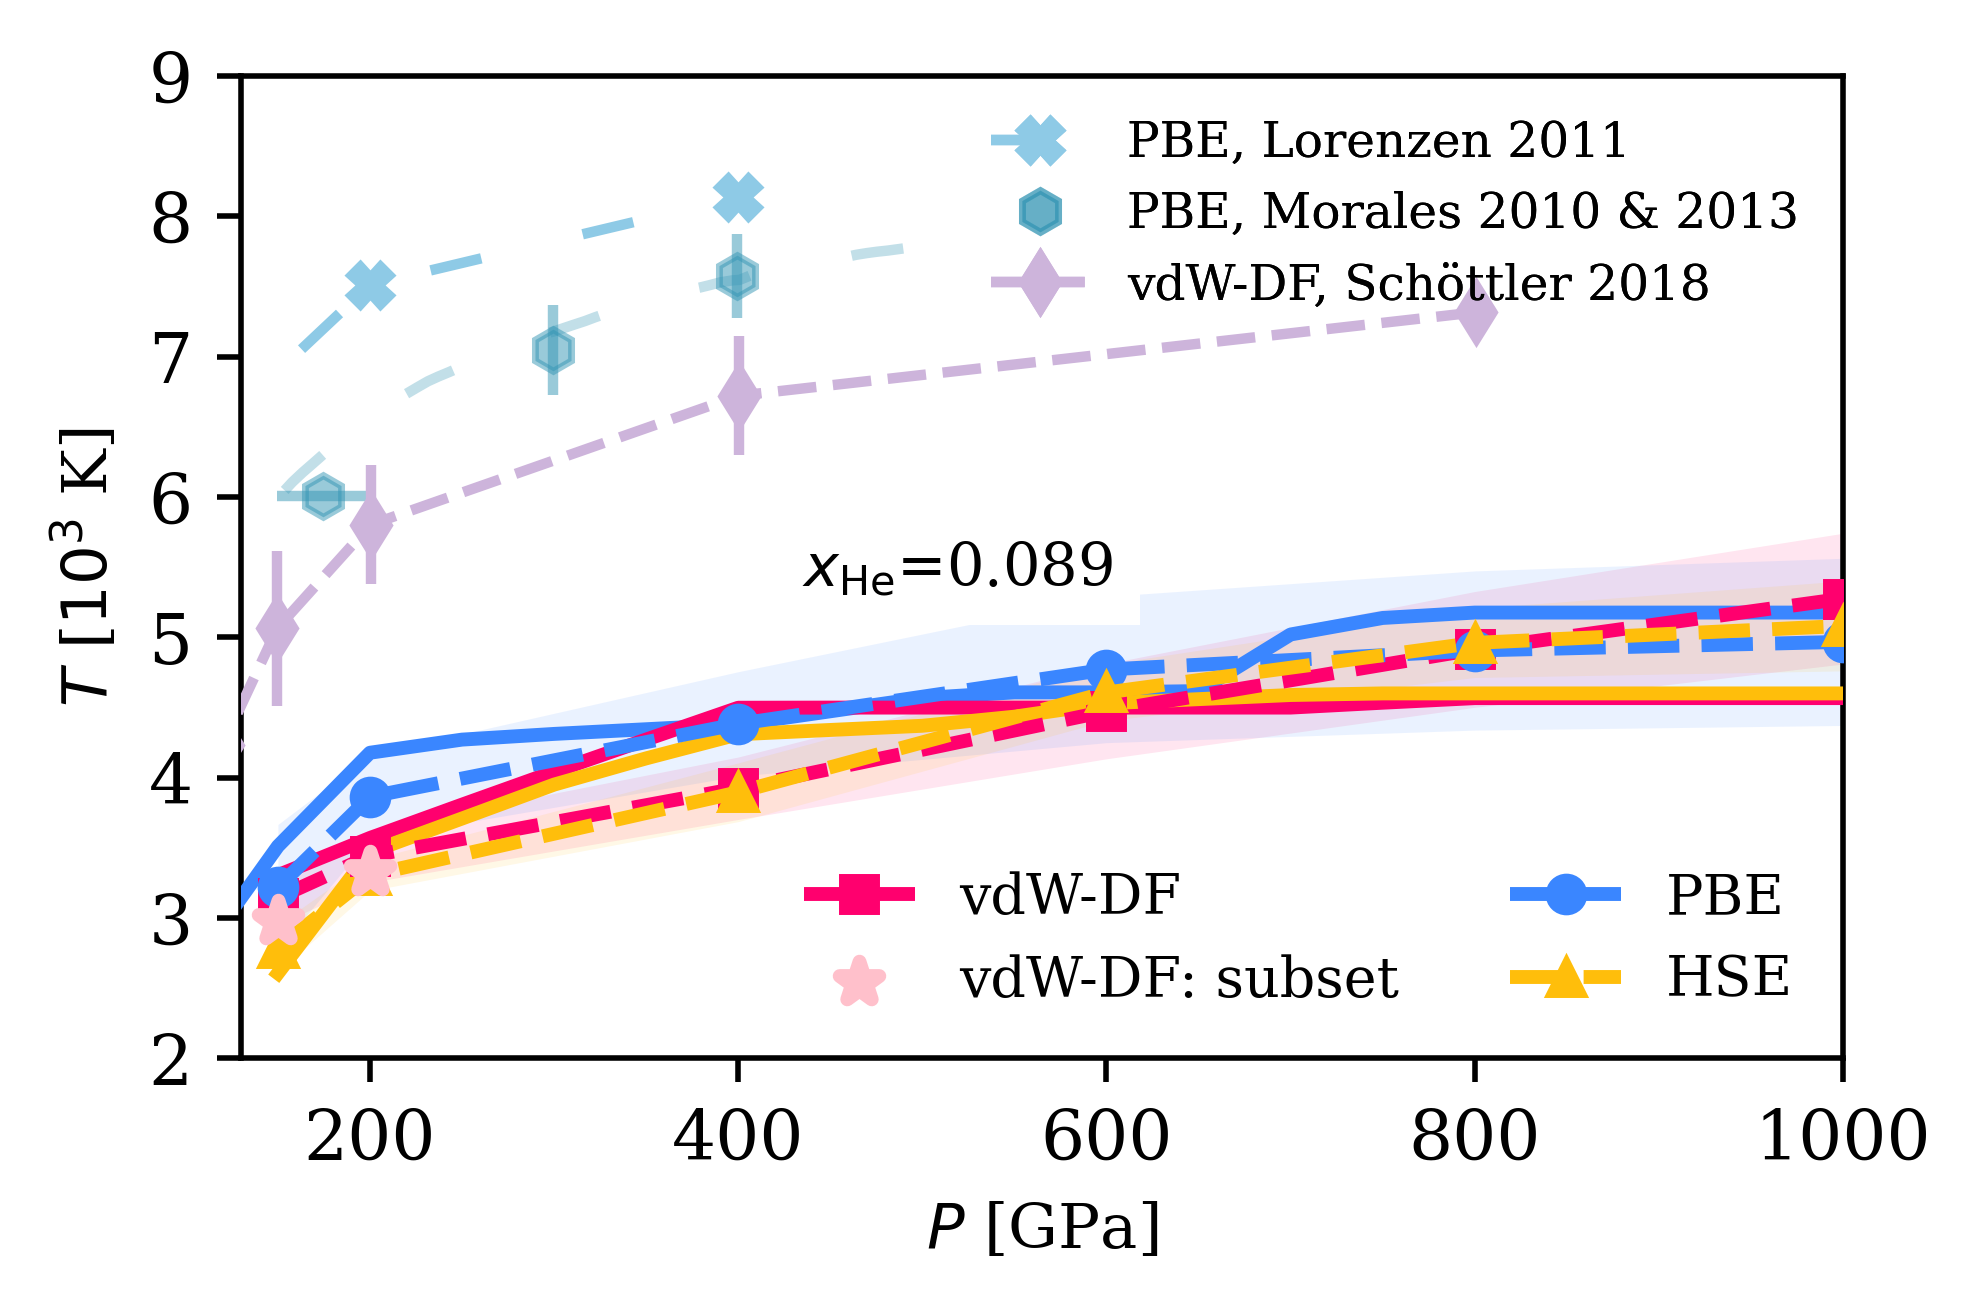

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Set font
font = {'family': 'serif', 'size': 10}
plt.rc('font', **font)

# Set figure size based on A4 paper
A4_width_mm = 210
fig_width_mm = A4_width_mm * 0.5
fig_height_mm = A4_width_mm * 0.5 / 1.62

fig_width_inches = fig_width_mm / 25.4
fig_height_inches = fig_height_mm / 25.4

fig, ax = plt.subplots(figsize=(fig_width_inches, fig_height_inches), dpi=500)

# Read data files
df_vdw = pd.read_csv("/Users/xiaoyuwang/Project/H-He/analysis_check/all_models_phase_boundaries_VDW.csv")
df_hse = pd.read_csv("/Users/xiaoyuwang/Project/H-He/analysis_check/all_models_phase_boundaries_HSE.csv")
df_pbe = pd.read_csv("/Users/xiaoyuwang/Project/H-He/analysis_check/all_models_phase_boundaries_PBE.csv")

# Filter for specific models
df_vdw_model = df_vdw[df_vdw['model_name'] == 'Model 2: Interaction']


df_hse_model = df_hse[df_hse['model_name'] == 'Model 5: Full-Quadratic']
df_pbe_model = df_pbe[df_pbe['model_name'] == 'Model 5: Full-Quadratic']

# Define colors and markers
colors_thermodynamic_model = ['#FF006E', '#3A86FF', '#FFBE0B']
labels = ['vdW-DF', 'PBE', 'HSE']
markers = ['s', 'o', '^']
# Lists to store handles for the first legend
lines_for_legend1 = []
# Plot data for each model
for i, (df, color, label, marker) in enumerate(zip([df_vdw_model, df_pbe_model, df_hse_model], 
                                                 colors_thermodynamic_model, 
                                                 labels, 
                                                 markers)):
    ax.fill_between(df["pressure_gpa"],
                     df["upper_bound_k"]/1e3,
                     df["lower_bound_k"]/1e3,
                     color=color, alpha=0.1,
                     edgecolor=color, linewidth=0,
                     zorder=1)
    
    line, = ax.plot(df['pressure_gpa'],
             df['mean_temp_k']/1e3,
             color=color, linewidth=2,
             marker=marker, markersize=5, label=label, ls="--",
             zorder=5)
    
    lines_for_legend1.append(line)


    if label == "vdW-DF":

        line = ax.scatter([150, 200], [2.98, 3.33], color="pink", marker="*", alpha=1, lw=2, zorder=9, label=f'vdW-DF: subset')
        lines_for_legend1.append(line)
# Create the first legend (for your models)


for label, (pressures, temperatures) in phase_boundaries.items():
    if label == "VDW":
        note = "vdW-DF"

        #line = ax.scatter([150, 200], [2.98, 3.33], color="pink", marker="*", alpha=1, lw=2, zorder=9, label=f'vdW-DF: subset')
        #lines_for_legend1.append(line)


    if label == "PBE":
        note = "PBE"
        #plt.scatter([150, 200], [3.33, 3.74], color=colors[label], marker="X",  alpha=1, lw=2, zorder=3, label=f'PA: {label}')
    
    if label == "HSE":
        note = "HSE"
        #plt.scatter([150, 200], [2.0, 3.8], color=colors[label], marker="X", alpha=1, lw=2, zorder=3, label=f'PA: {label}')


    file_path = f"/Users/xiaoyuwang/Project/H-He/analysis_check/{label}_contour_data.csv"

    try:
        data = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error loading {label} data: {str(e)}")
        continue
    #plt.plot(pressures, temperatures/1e3, label=f"{note}, this work", color=colors[label], marker=markers[label], lw=2, ls='--', clip_on=False, zorder=10)

    data = data[data['x_He'] == 0.089]
    pressures = data['Pressure']
    temperatures = data['Temperature']
    ax.plot(pressures, temperatures/1e3, color=colors[label],  alpha=1, lw=2, zorder=3)

first_legend = ax.legend(handles=lines_for_legend1, fontsize=8, ncol=2, frameon=True, loc='lower right', facecolor='none', edgecolor='none')
ax.add_artist(first_legend)

# Lists to store handles for the second legend
lines_for_legend2 = []

lorenzen, = ax.plot(data_Lorenzen_2011[:,0]*100, data_Lorenzen_2011[:,1], label='PBE, Lorenzen 2011', ls=(0, (5, 10)), marker="X", color='#8ECAE6', markersize=6, clip_on=True)
lines_for_legend2.append(lorenzen)

# Get the line artist from errorbar and set its label
morales_line, _, _ = ax.errorbar(high_pressure_data[:,0], high_pressure_data[:,1]/1e3,
             yerr=high_pressure_data[:,2]/1e3,
             label='_nolegend_', # Set initial label to '_nolegend_'
             ls='', marker="h",
             color='#3596b5', alpha=0.5, markersize=6, clip_on=True)
morales_line.set_label('PBE, Morales 2010 & 2013') # Explicitly set the label for the line artist
lines_for_legend2.append(morales_line)

ax.errorbar(low_pressure_data[:,0], low_pressure_data[:,1]/1e3,
             xerr=low_pressure_data[:,3],
             # This errorbar is not intended for the legend, so no changes needed here.
             ls='', marker="h",
             color='#3596b5', alpha=0.5, markersize=6, clip_on=True)

ax.plot(data_Morales_2013_line[:,0]*100, data_Morales_2013_line[:,1],
         ls=(0, (5, 10)), color='#3596b5', alpha=0.3, clip_on=True)

# Get the line artist from errorbar and set its label
schottler_line, _, _ = ax.errorbar(data_Schöttler_2018[:,0]*100, data_Schöttler_2018[:,1], yerr=data_Schöttler_2018[:,2]/1000, label='_nolegend_', ls="dashed", marker="d", color='#cdb4db',alpha = 1.0, markersize=6,zorder=3, clip_on=True)
schottler_line.set_label('vdW-DF, Schöttler 2018') # Explicitly set the label for the line artist
lines_for_legend2.append(schottler_line)

#chang, = ax.plot(data_Chang_2024[:,0]*100, data_Chang_2024[:,1], label='vdW-DF, Chang 2024', marker=">", color='#CDB4DB',  ls=(0, (3, 1, 1, 1, 1, 1)),  alpha=1.0, markersize=6, clip_on=True)
#lines_for_legend2.append(chang)

#chang_rvv10, = ax.plot(data_Chang_2024_rVV10[:,0]*100, data_Chang_2024_rVV10[:,1], label='SCAN+rVV10, Chang 2024', marker="<", color='#74a892', ls=(0, (3, 1, 1, 1, 1, 1)),  alpha=0.7, markersize=6, clip_on=True)
#lines_for_legend2.append(chang_rvv10)

# Create the second legend (for previous studies)
second_legend = ax.legend(handles=lines_for_legend2, fontsize=7, ncol=1, frameon=True, loc='upper right', facecolor='none', edgecolor='none')
ax.add_artist(second_legend)


# Add labels and formatting
plt.grid(False)
plt.xlabel(r'$P$ [GPa]', fontsize=9)
plt.ylabel(r'$T$ [$10^3$ K]', fontsize=9)
plt.ylim(2,9)
plt.xlim(130, 1000)
#plt.legend(fontsize=8, ncol=3, edgecolor='None', loc='upper left')

# Add annotation
plt.annotate(rf'$x_{{\mathrm{{He}}}}$=0.089',
            (500, 5),
            xytext=(5, 10),
            textcoords='offset points',
            ha='center',
            va='center',
            fontsize=8.5,
            color='black',
            zorder=6,
            bbox=dict(facecolor='white', edgecolor='none'))

plt.savefig('/Users/xiaoyuwang/Project/H-He/H-He-demixing/Figs/Fig2_R-K_model_predictions.pdf', dpi=500, bbox_inches='tight')
plt.show()

# compare 3rd-RK and 5th-RK

TypeError: unsupported operand type(s) for /: 'str' and 'float'

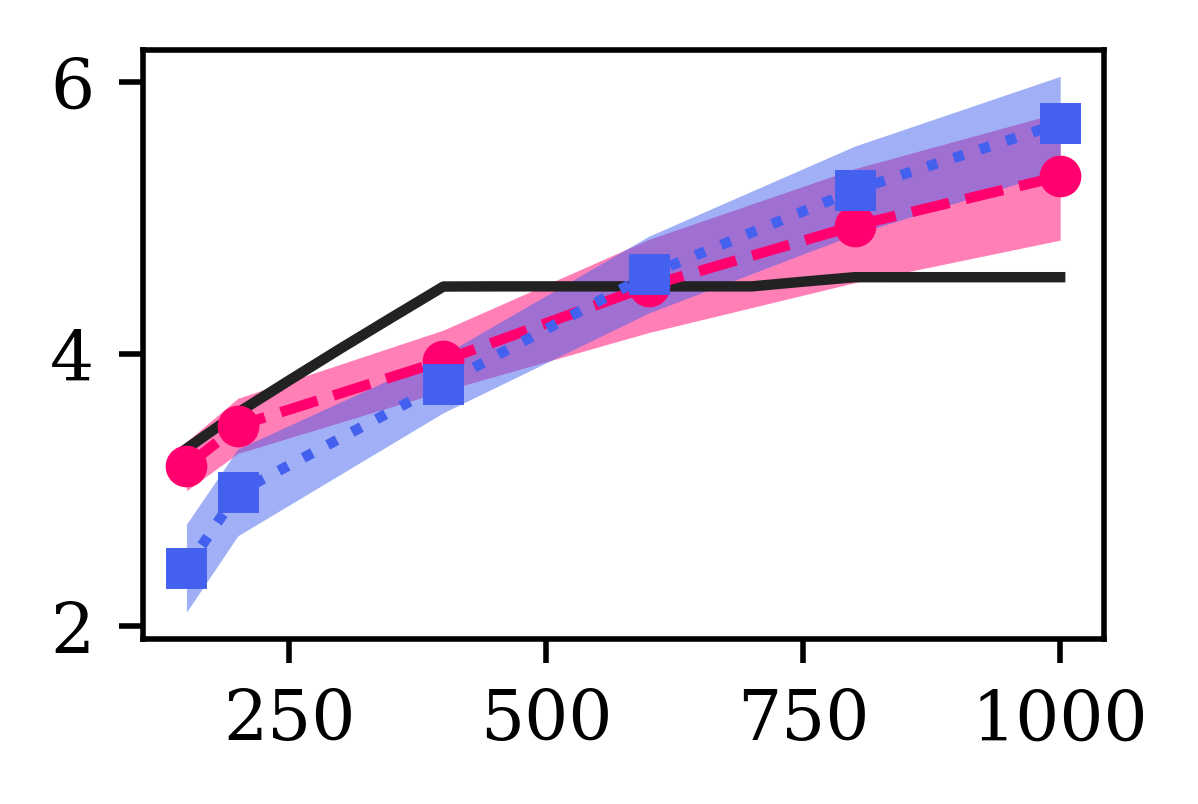

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置字体
font = {'family': 'serif', 'size': 10}
plt.rc('font', **font)
# 设置图像尺寸（A4纸宽度的一半）
A4_width_mm = 210
fig_width_mm = A4_width_mm * 0.3
fig_height_mm = fig_width_mm / 1.62
fig_width_inches = fig_width_mm / 25.4
fig_height_inches = fig_height_mm / 25.4
fig, ax = plt.subplots(figsize=(fig_width_inches, fig_height_inches), dpi=500)

# 读取3rd-RK和5th-RK的vdW-DF数据（统一用analysis_check）
df_vdw_3rd = pd.read_csv("/Users/xiaoyuwang/Project/H-He/analysis_check/vdW_DF_phase_boundary_3rd_RK.csv")
df_vdw_5th = pd.read_csv("/Users/xiaoyuwang/Project/H-He/analysis_check/all_models_phase_boundaries_VDW_5th.csv")

# 只保留 Model 2: Interaction
model_name = "Model 2: Interaction"
df_vdw_3rd = df_vdw_3rd[df_vdw_3rd["model_name"] == model_name].copy()
df_vdw_5th = df_vdw_5th[df_vdw_5th["model_name"] == model_name].copy()

# 列名转换到模板格式
df_vdw_3rd = df_vdw_3rd.rename(columns={
    "pressure_gpa": "pressure",
    "mean_temp_k": "mean_temp",
    "std_temp_k": "std_temp",
    "upper_bound_k": "upper_bound",
    "lower_bound_k": "lower_bound"
})
df_vdw_5th = df_vdw_5th.rename(columns={
    "pressure_gpa": "pressure",
    "mean_temp_k": "mean_temp",
    "std_temp_k": "std_temp",
    "upper_bound_k": "upper_bound",
    "lower_bound_k": "lower_bound"
})

# 按压力排序，保证画线顺序
df_vdw_3rd = df_vdw_3rd.sort_values("pressure")
df_vdw_5th = df_vdw_5th.sort_values("pressure")

# 读取直接AIMD计算的vdW-DF数据
df_vdw_aimd = pd.read_csv("/Users/xiaoyuwang/Project/H-He/analysis_check/VDW_contour_data.csv")
df_vdw_aimd = df_vdw_aimd[df_vdw_aimd['x_He'] == 0.089]

# 读取 CT 数据并进行切片 (行 3 到行 20, 索引为 0-based, 2-19)
df_ct = pd.read_csv("/Users/xiaoyuwang/Desktop/Common-tangent_vdW-DF/VDW_contour_data_CT.csv", header=None, names=["Pressure", "Temperature", "x_He", "Label"])
df_ct = df_ct.iloc[2:20]  # 取第3-20行

# 颜色和样式（完全按模板）
color_3rd = '#FF006E'
color_5th = '#4361EE'
color_aimd = '#222222'
marker_3rd = 'o'
marker_5th = 's'
marker_aimd = 'D'

# 绘制3rd-RK
ax.fill_between(df_vdw_3rd["pressure"],
                df_vdw_3rd["upper_bound"] / 1e3,
                df_vdw_3rd["lower_bound"] / 1e3,
                color=color_3rd, alpha=0.5,
                edgecolor=color_3rd, linewidth=0,
                zorder=1)
line_3rd, = ax.plot(df_vdw_3rd['pressure'],
                    df_vdw_3rd['mean_temp'] / 1e3,
                    color=color_3rd, linewidth=1.5,
                    marker=marker_3rd, markersize=5, label='vdW-DF 3rd R-K', ls="--",
                    zorder=5)

# 绘制5th-RK
ax.fill_between(
    df_vdw_5th["pressure"],
    (df_vdw_5th["mean_temp"] - df_vdw_5th["std_temp"]) / 1e3,
    (df_vdw_5th["mean_temp"] + df_vdw_5th["std_temp"]) / 1e3,
    color=color_5th, alpha=0.5,
    edgecolor=color_5th, linewidth=0,
    zorder=2
)
line_5th, = ax.plot(
    df_vdw_5th['pressure'],
    df_vdw_5th['mean_temp'] / 1e3,
    color=color_5th, linewidth=1.5,
    marker=marker_5th, markersize=5, label='vdW-DF 5th R-K', ls="dotted",
    zorder=6
)

# 绘制直接AIMD计算结果
line_aimd, = ax.plot(df_vdw_aimd['Pressure'],
                     df_vdw_aimd['Temperature'] / 1e3,
                     color=color_aimd, linewidth=1.5,
                     label='vdW-DF MLP MD', ls="-",
                     zorder=3)

# 添加 CT 的虚线
ct_line, = ax.plot(
    df_ct["Pressure"],
    df_ct["Temperature"] / 1e3,
    color='black',
    linewidth=1.2,
    linestyle="--",
    label='CT (vdW-DF, x_He=0.089)',
    zorder=7,
)

# 图例
first_legend = ax.legend(handles=[line_3rd, line_5th, line_aimd, ct_line], fontsize=8, ncol=1, frameon=True, loc='lower right', facecolor='none', edgecolor='none')
ax.add_artist(first_legend)

# 格式设置
plt.grid(False)
plt.xlabel(r'$P$ [GPa]', fontsize=9)
plt.ylabel(r'$T$ [$10^3$ K]', fontsize=9)
plt.ylim(2, 6)
plt.xlim(130, 1000)

# 注释
plt.annotate(
    rf'$x_{{\mathrm{{He}}}}$=0.089',
    (140, 5.99),  # 图片左上角，x轴最小值略右，y轴最大值略下
    xytext=(5, -2),
    textcoords='offset points',
    ha='left',
    va='top',
    fontsize=8.5,
    color='black',
    zorder=6,
    bbox=dict(facecolor='none', edgecolor='none')
)
plt.savefig('/Users/xiaoyuwang/Project/H-He/H-He-demixing/Figs/S2_R-K_model_predictions_compare_vdW-DF.pdf', dpi=500, bbox_inches='tight')
plt.show()